# PyTorch

## Instalación de dependencias

In [59]:
%%capture
uv pip install torch torchvision numpy matplotlib scikit-learn seaborn

## Importar librerías

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# PyTorch 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

## Importar imágenes 

In [61]:
from get_images import get_images

In [62]:
# MNIST path
mnist_path = '../data/mnist'
x_train_num, y_train_num, x_test_num, y_test_num = get_images(mnist_path)

x_train = x_train_num[:50000].reshape(50000, -1).astype(np.float32)
y_train = y_train_num[:50000].reshape(50000, 1)

x_val = x_train_num[50000:].reshape(10000, -1).astype(np.float32)
y_val = y_train_num[50000:].reshape(10000, 1)

x_test = x_test_num.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test_num.copy().reshape(10000, 1)

## Normalizar imágenes

$$x_n= (x - μ) / σ$$

Donde:
- $μ$ = media de todo el training set
- $σ$ = desviación estándar del training set

In [63]:
def normalise(x_mean, x_std, x_data):
    return (x_data - x_mean) / x_std

In [64]:
x_mean = x_train.mean()
x_std = x_train.std()

x_train = normalise(x_mean, x_std, x_train)
x_val = normalise(x_mean, x_std, x_val)
x_test = normalise(x_mean, x_std, x_test)

In [65]:
x_train.mean(), x_train.std()

(np.float32(9.0680805e-09), np.float32(1.0))

## Mostrar imágenes 

In [66]:
x_test.shape

(10000, 784)

In [67]:
y_train.shape

(50000, 1)

In [68]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

La imagen muestreada representa un: 4


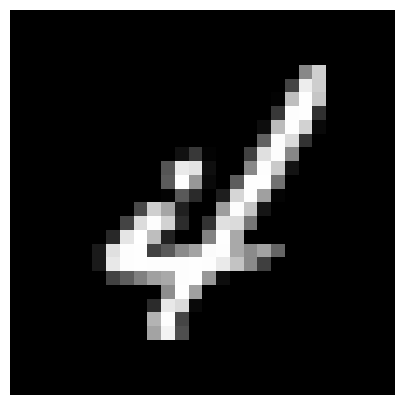

In [71]:
rnd_idx = np.random.randint(len(y_test))
print(f'La imagen muestreada representa un: {y_test[rnd_idx, 0]}')
plot_number(x_test_num[rnd_idx])

## PyTorch

## Convertir Numpy array a PyTorch (Tensores)

Un **tensor** es como un arreglo multidimensional de números. Es la forma en que PyTorch almacenan y procesa datos.

In [72]:
x_train_tensor = torch.tensor(x_train.copy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.copy(), dtype=torch.long).squeeze()

x_val_tensor = torch.tensor(x_val.copy(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.copy(), dtype=torch.long).squeeze()

x_test_tensor = torch.tensor(x_test.copy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.copy(), dtype=torch.long).squeeze()

## Usar GPU de estar disponible

In [73]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU disponible: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
print(f'Dispositivo seleccionado: {device}')

GPU disponible: NVIDIA RTX A2000 Laptop GPU
Dispositivo seleccionado: cuda


In [74]:
print(f'Train: {x_train_tensor.shape}, {y_train_tensor.shape}')
print(f'Val: {x_val_tensor.shape}, {y_val_tensor.shape}')
print(f'Test: {x_test_tensor.shape}, {y_test_tensor.shape}')

Train: torch.Size([50000, 784]), torch.Size([50000])
Val: torch.Size([10000, 784]), torch.Size([10000])
Test: torch.Size([10000, 784]), torch.Size([10000])


## Crear DataLoaders de PyTorch

Un **DataLoader** es como un "repartidor de datos" que entrega tus datos en pequeños lotes (batches) durante el entrenamiento.

In [75]:
# Crear datasets
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# Configuración de batch size
batch_size = 512

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Batches de entrenamiento: {len(train_loader)}')
print(f'Batches de validación: {len(val_loader)}')
print(f'Batches de test: {len(test_loader)}')

Batches de entrenamiento: 98
Batches de validación: 20
Batches de test: 20


## Función de evaluación

In [76]:
def evaluate(model, data_loader, device):
    """
    Evalúa el modelo en un DataLoader y retorna accuracy y loss promedio
    """
    correct = 0
    total = 0
    total_loss = 0.0
    model = model.to(device=device)
    
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
        
            outputs = model(x_batch)
            loss = F.cross_entropy(outputs, y_batch)
            total_loss += loss.item()
            
            _, predicted = outputs.max(dim=1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()
    
    accuracy = correct / total
    avg_loss = total_loss / len(data_loader)
    return accuracy, avg_loss

## Loop de entrenamiento

In [77]:
def train_model(model, train_loader, val_loader, optimizer, device, epochs=20):
    """
    Entrena el modelo usando PyTorch DataLoaders
    """
    model = model.to(device)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Forward pass
            outputs = model(x_batch)
            loss = F.cross_entropy(outputs, y_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Evaluar en validación
        val_acc, val_loss = evaluate(model, val_loader, device)
        avg_train_loss = train_loss / len(train_loader) # costo
        
        print(f'Epoch {epoch+1}/{epochs} - '
              f'Train Loss: {avg_train_loss:.4f} - '
              f'Val Loss: {val_loss:.4f} - '
              f'Val Acc: {val_acc:.4f} ({val_acc*100:.2f}%)')
    
    return model

## Definir y entrenar el modelo

### SGD (Stochastic Gradient Descent)

1. Actualización de Pesos ($W$)

    Los pesos se ajustan restando el producto de la tasa de aprendizaje $\alpha$ por el gradiente de la función de pérdida respecto a $W$:

$$W_{t+1} = W_t - \alpha \frac{\partial J}{\partial W}$$

2. Actualización de Sesgos ($b$)

    De igual forma, el sesgo se desplaza en la dirección opuesta al gradiente para reducir el error:

$$b_{t+1} = b_t - \alpha \frac{\partial J}{\partial b}$$


In [78]:
# Hiperparámetros
hidden1 = 200
hidden2 = 200
learning_rate = 0.01
epochs = 20

# Crear modelo
model = nn.Sequential(
    nn.Linear(784, hidden1),
    nn.ReLU(),
    nn.Linear(hidden1, hidden2),
    nn.ReLU(),
    nn.Linear(hidden2, 10)
)

# Optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

print(f'Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros')

Modelo creado con 199210 parámetros


In [79]:
# Entrenar el modelo
model = train_model(model, train_loader, val_loader, optimizer, device, epochs=epochs)

Epoch 1/20 - Train Loss: 2.1285 - Val Loss: 1.8619 - Val Acc: 0.6847 (68.47%)
Epoch 2/20 - Train Loss: 1.4720 - Val Loss: 1.0541 - Val Acc: 0.7975 (79.75%)
Epoch 3/20 - Train Loss: 0.8656 - Val Loss: 0.6615 - Val Acc: 0.8562 (85.62%)
Epoch 4/20 - Train Loss: 0.6207 - Val Loss: 0.5090 - Val Acc: 0.8756 (87.56%)
Epoch 5/20 - Train Loss: 0.5125 - Val Loss: 0.4348 - Val Acc: 0.8884 (88.84%)
Epoch 6/20 - Train Loss: 0.4523 - Val Loss: 0.3908 - Val Acc: 0.8958 (89.58%)
Epoch 7/20 - Train Loss: 0.4146 - Val Loss: 0.3625 - Val Acc: 0.9007 (90.07%)
Epoch 8/20 - Train Loss: 0.3882 - Val Loss: 0.3426 - Val Acc: 0.9040 (90.40%)
Epoch 9/20 - Train Loss: 0.3685 - Val Loss: 0.3271 - Val Acc: 0.9068 (90.68%)
Epoch 10/20 - Train Loss: 0.3525 - Val Loss: 0.3145 - Val Acc: 0.9098 (90.98%)
Epoch 11/20 - Train Loss: 0.3394 - Val Loss: 0.3041 - Val Acc: 0.9133 (91.33%)
Epoch 12/20 - Train Loss: 0.3281 - Val Loss: 0.2955 - Val Acc: 0.9149 (91.49%)
Epoch 13/20 - Train Loss: 0.3183 - Val Loss: 0.2875 - Val Acc

## Evaluar en test set

In [80]:
test_acc, test_loss = evaluate(model, test_loader, device)
print(f'\nResultados en Test Set:')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test Loss: {test_loss:.4f}')


Resultados en Test Set:
Test Accuracy: 0.9268 (92.68%)
Test Loss: 0.2605


## Predicción individual

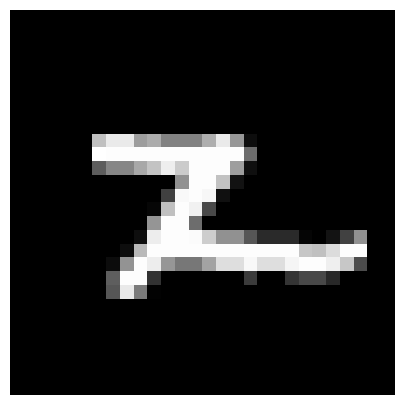

Predicción: 8
Valor real: 2
Confianza: 43.65%


In [89]:
model.eval()
idx = np.random.randint(len(y_test))
plot_number(x_test_num[idx])

with torch.no_grad():
    x_sample = x_test_tensor[idx].unsqueeze(0).to(device)
    output = model(x_sample)
    pred = output.argmax(dim=1).item()
    probs = F.softmax(output, dim=1)[0]
    
print(f'Predicción: {pred}')
print(f'Valor real: {y_test[idx, 0]}')
print(f'Confianza: {probs[pred].item()*100:.2f}%')

## Matriz de Confusión

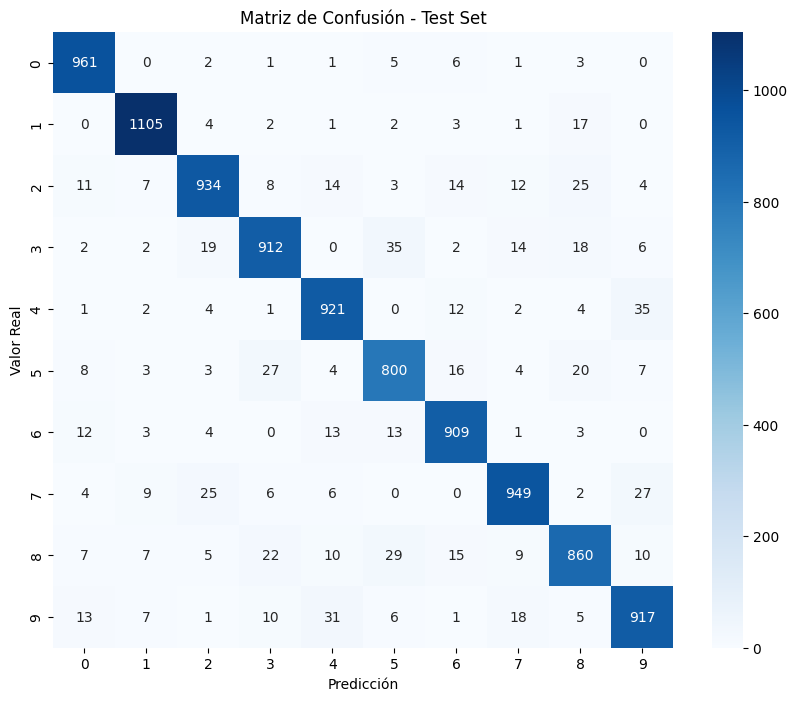

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtener todas las predicciones
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        outputs = model(x_batch)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

# Crear matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Test Set')
plt.show()

## Guardar Modelo

In [ ]:
model_path = '../models/modelMNIST.pth'

In [93]:
torch.save(
    model.state_dict(),
    model_path
)

In [94]:
 model.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0272, -0.0184, -0.0319,  ...,  0.0102,  0.0117, -0.0002],
                      [-0.0209, -0.0348, -0.0133,  ...,  0.0217,  0.0313,  0.0257],
                      [ 0.0152, -0.0306,  0.0188,  ...,  0.0285, -0.0306,  0.0034],
                      ...,
                      [-0.0109, -0.0159, -0.0014,  ...,  0.0216, -0.0171, -0.0070],
                      [ 0.0175,  0.0208, -0.0345,  ...,  0.0314, -0.0266, -0.0314],
                      [-0.0238,  0.0039,  0.0058,  ..., -0.0064,  0.0046, -0.0333]],
                     device='cuda:0')),
             ('0.bias',
              tensor([-0.0283,  0.0314,  0.0067,  0.0326,  0.0191,  0.0179,  0.0136, -0.0063,
                       0.0430, -0.0218,  0.0215,  0.0145, -0.0020,  0.0096,  0.0157,  0.0015,
                      -0.0127, -0.0147, -0.0128,  0.0193, -0.0029, -0.0276, -0.0188,  0.0276,
                      -0.0208,  0.0214,  0.0141,  0.0228, -0.0299, -0.0046,  0.0321,  0.0151,
  

### Opción 2

In [95]:
model_completo_path = '../models/modelMNIST_completo.pth'

In [96]:
torch.save(model, model_completo_path)

## Cargar Modelo Completo

In [ ]:
# Cargar el modelo completo guardado
loaded_model = torch.load(model_completo_path, map_location=device)
loaded_model.eval()
loaded_model.to(device)

print("✓ Modelo completo cargado exitosamente")
print(f"  Dispositivo: {device}")
print(f"  Ubicación: {model_completo_path}")

### Verificar que el modelo cargado funciona correctamente

In [ ]:
# Evaluar el modelo cargado en el test set
test_acc_loaded, test_loss_loaded = evaluate(loaded_model, test_loader, device)

print("="*60)
print("VERIFICACIÓN DEL MODELO CARGADO")
print("="*60)
print(f"Test Accuracy: {test_acc_loaded:.4f} ({test_acc_loaded*100:.2f}%)")
print(f"Test Loss:     {test_loss_loaded:.4f}")
print("="*60)

### Probar con una imagen aleatoria

In [ ]:
# Seleccionar imagen aleatoria
idx = np.random.randint(len(y_test))

# Visualizar la imagen
plot_number(x_test_num[idx])

# Hacer predicción con el modelo cargado
loaded_model.eval()
with torch.no_grad():
    x_sample = x_test_tensor[idx].unsqueeze(0).to(device)
    output = loaded_model(x_sample)
    pred = output.argmax(dim=1).item()
    probs = F.softmax(output, dim=1)[0]

# Mostrar resultados
print("="*60)
print(f"Índice de imagen:        {idx}")
print(f"Valor real:              {y_test[idx, 0]}")
print(f"Predicción (modelo cargado): {pred}")
print(f"Confianza:               {probs[pred].item()*100:.2f}%")
print("="*60)

# Mostrar top 3 predicciones
print("\nTop 3 predicciones:")
top3_probs, top3_indices = torch.topk(probs, 3)
for i in range(3):
    digit = top3_indices[i].item()
    prob = top3_probs[i].item() * 100
    bar = "█" * int(prob / 5)  # Barra visual
    print(f"  {digit}: {prob:5.2f}% {bar}")
print("="*60)

# Verificar si la predicción es correcta
if pred == y_test[idx, 0]:
    print("\n✓ ¡Predicción CORRECTA!")
else:
    print(f"\n✗ Predicción INCORRECTA (esperaba {y_test[idx, 0]})")

### Probar con múltiples imágenes aleatorias

In [ ]:
# Probar con 10 imágenes aleatorias
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

loaded_model.eval()
correctas = 0
total = 10

print("Probando 10 imágenes aleatorias con el modelo cargado...")
print("="*60)

for i in range(total):
    idx = np.random.randint(len(y_test))
    
    # Mostrar imagen
    axes[i].imshow(x_test_num[idx].squeeze(), cmap='gray')
    axes[i].axis('off')
    
    # Predecir
    with torch.no_grad():
        x_sample = x_test_tensor[idx].unsqueeze(0).to(device)
        output = loaded_model(x_sample)
        pred = output.argmax(dim=1).item()
        probs = F.softmax(output, dim=1)[0]
        confidence = probs[pred].item() * 100
    
    real = y_test[idx, 0]
    color = 'green' if pred == real else 'red'
    
    axes[i].set_title(f'Real: {real}\nPred: {pred}\n{confidence:.1f}%', 
                     color=color, fontsize=10, fontweight='bold')
    
    if pred == real:
        correctas += 1

plt.suptitle('Predicciones del Modelo Cargado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nResultados:")
print(f"  Correctas: {correctas}/{total}")
print(f"  Precisión: {correctas/total*100:.1f}%")
print("="*60)